In [180]:

import networkx as nx
from networkx.algorithms import community

import sys
import os
import warnings
from collections import defaultdict
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Wedge
import json
import lzma
import math
from collections import defaultdict, deque, Counter
from itertools import combinations

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics import fowlkes_mallows_score
from sklearn.preprocessing import StandardScaler


from gensim.models import Word2Vec

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


In [181]:
CLASSES_PATH = os.path.dirname(os.path.abspath('D:/Code/Classes/'))
if not (CLASSES_PATH in sys.path):
    sys.path.append(CLASSES_PATH)
from Classes.Files_Handler_Class import Files_Handler
from Classes.Bcolors_Class import Bcolors as bcolors
from Classes.Load_Graph import Load_Graph
from Classes.Generate_Embedings import Generate_Embedings
from Classes.Random_Walk import Random_Walk
from Classes.K_Shell_Calculate_Class import K_Shell_Calculate

In [182]:
files_handler_obj = Files_Handler()
Load_Graph = Load_Graph()
Gnerate_Embedings = Generate_Embedings()
Random_Walk = Random_Walk()

In [183]:
accepable_files = ['.edgeslist', '.edges', '.txt']
networks_file = files_handler_obj.select_files('text', accepable_files, 
                                                   'Select Network File', False)
file_info = files_handler_obj.get_file_path_info(networks_file)   
file_info

{'path': 'D:/Datasets/CD/Multiplex/My Networks/',
 'name': 'Gpt Network',
 'type': '.txt'}

In [184]:
network_folder_path = file_info['path'] + file_info['name'] + "/"

In [185]:
ConvAE_best_loss = True
universal_models = False
if universal_models == True:
    models_path = files_handler_obj.select_dir()
    models_path_parts = models_path.split("/")
    if models_path_parts[-1] != "Trained Models":
        models_path += "/Trained Models/"
    else:
        models_path += "/"
    print(models_path)


In [ ]:
method_name = "USCALE"

In [187]:
if file_info['type'] == ".mat":
    graphs_of_network, nodes_list, labels = Load_Graph.load_multilayer_graph(file_path=networks_file, network_type="Matlab File", 
                                                          directed=False, delimiter=None, tabs="", print_layer_info=True)
        
elif file_info['type'] == ".edges" or file_info['type'] == ".txt" or file_info['type'] == ".edgeslist":
    graphs_of_network, nodes_list, labels = Load_Graph.load_multilayer_graph(file_path=networks_file, network_type= "Multiplex Edges",#"Multiplex Edges", 
                                                          directed=False, delimiter=None, tabs="", print_layer_info=True)
    
 

Layer 1: 22 Node And 36 Edge
Layer 2: 22 Node And 33 Edge
Layer 3: 22 Node And 30 Edge
Network with 22 nodes and 3 layers loaded successfully.


In [188]:
sum(dict(graphs_of_network[0].degree()).values())/len(graphs_of_network[0].degree())

3.272727272727273

In [229]:
def multiplex_to_weighted_graph(layers):
    """
    layers: list of networkx graphs
    return: aggregated weighted graph
    """
    edge_weights = defaultdict(int)

    # شمارش یال‌ها در تمام لایه‌ها
    for G in layers:
        for u, v in G.edges():
            if u > v:   # یکنواخت‌سازی ترتیب، مخصوص گراف‌های بدون جهت
                u, v = v, u
            edge_weights[(u, v)] += 1
    # ساخت گراف جدید وزن‌دار
    H = nx.Graph()
    for (u, v), w in edge_weights.items():
        H.add_edge(u, v, weight=w)

    return H

def find_anchor_nodes(
    G: nx.Graph,
    weight: str = "weight",
    att_name:str= "anchor_score",
    z_min: float = 2.5,
    min_percentile: float = 85.0,
):
    """
    Automatically extract Anchor Nodes from a weighted, undirected graph.

    Parameters
    ----------
    G : nx.Graph
        Undirected weighted graph
    weight : str
        Edge weight attribute
    z_min : float
        Robust z-score threshold
    min_percentile : float
        Minimum percentile cutoff for anchor score

    Returns
    -------
    anchors : list
        List of anchor node IDs
    anchor_scores : dict
        Node -> anchor score
    """

    if G.number_of_nodes() == 0:
        return [], {}

    # ---------- Step 1: weighted degree ----------
    wdeg = dict(G.degree(weight=weight))
    max_wdeg = max(wdeg.values()) if wdeg else 1.0

    # ---------- Step 2: anchor score computation ----------
    anchor_score = {}

    for node in G.nodes():
        neighbors = list(G.neighbors(node))
        if not neighbors:
            anchor_score[node] = 0.0
            continue

        weights = []
        entropy = 0.0
        cohesion = 0.0

        ki = wdeg[node]
        if ki == 0:
            anchor_score[node] = 0.0
            continue

        for nbr in neighbors:
            w = G[node][nbr].get(weight, 1.0)
            weights.append(w)

            # structural entropy
            p = w / ki
            entropy -= p * math.log(p + 1e-12)


        # concentration (dominant neighbor)
        max_w = max(weights)
        concentration = max_w / ki

        # structural entropy
        entropy /= math.log(len(weights) + 1e-12)

        # local cohesion
        for nbr in neighbors:
            w = G[node][nbr].get(weight, 1.0)
            cohesion += w * (wdeg[nbr] / max_wdeg)

        cohesion /= ki

        # normalized degree
        deg_norm = ki / max_wdeg

        # final anchor score
        anchor_score[node] = (
            (0.35 * deg_norm)
            + (0.25 * (1.0 - entropy))
            + (0.20 * concentration)
            + (0.20 * cohesion)
        )

    # ---------- Step 3: robust statistics ----------
    scores = np.array(list(anchor_score.values()))
    median = np.median(scores)
    mad = np.median(np.abs(scores - median)) + 1e-12

    robust_z = {
        node: (score - median) / mad
        for node, score in anchor_score.items()
    }

    percentile_cut = np.percentile(scores, min_percentile)

    # ---------- Step 4: adaptive anchor selection ----------
    avg_degree = sum(dict(G.degree()).values())/len(G.degree())
    anchors = [
        node
        for node in G.nodes()
        if robust_z[node] >= z_min and anchor_score[node] >= percentile_cut
    ]

    # ---------- Step 5: size control ----------
    n = G.number_of_nodes()
    min_size = max(1, int(math.log(n + 1)))
    max_size = int(0.1 * n)

    if len(anchors) < min_size:
        anchors = sorted(anchor_score, key=anchor_score.get, reverse=True)[:min_size]
    elif len(anchors) > max_size:
        anchors = sorted(anchors, key=lambda x: anchor_score[x], reverse=True)[:max_size]

    nx.set_node_attributes(G, 0, att_name)
    for node in G.nodes():
        G.nodes[node][att_name] = anchor_score[node]

    return G, anchors, anchor_score

def improved_anchor_selection(
    G,
    att_name:str= "anchor_score",
    weight="weight",
    z_min=2.0,
    min_percentile=80,
    min_degree=2,
    min_core=2,
):


    if G.number_of_nodes() == 0:
        return [], {}

    # ---------- weighted degree ----------
    wdeg = dict(G.degree(weight=weight))
    max_wdeg = max(wdeg.values()) + 1e-12

    # ---------- clustering ----------
    clustering = nx.clustering(G, weight=weight)

    # ---------- k-core ----------
    core_num = nx.core_number(G)
    max_core = max(core_num.values()) + 1e-12

    scores = {}

    for node in G.nodes():

        deg = wdeg[node]

        # hard filtering
        if deg < min_degree:
            scores[node] = 0
            continue

        if core_num[node] < min_core:
            scores[node] = 0
            continue

        nbrs = list(G.neighbors(node))

        if len(nbrs) == 0:
            scores[node] = 0
            continue

        # entropy
        entropy = 0
        weights = []

        for nbr in nbrs:
            w = G[node][nbr].get(weight, 1.0)
            weights.append(w)

            p = w / (deg + 1e-12)
            entropy -= p * math.log(p + 1e-12)

        entropy /= math.log(len(nbrs) + 1e-12)

        # concentration
        concentration = max(weights) / (deg + 1e-12)

        # degree-normalized concentration
        concentration *= math.log1p(deg)

        # local cohesion
        cohesion = 0

        for nbr in nbrs:
            w = G[node][nbr].get(weight, 1.0)
            cohesion += w * (wdeg[nbr] / max_wdeg)

        cohesion /= (deg + 1e-12)

        # normalized metrics
        deg_norm = deg / max_wdeg
        cluster_norm = clustering[node]
        core_norm = core_num[node] / max_core

        # final score
        score = (
            0.30 * deg_norm
            + 0.25 * cohesion
            + 0.20 * cluster_norm
            + 0.15 * core_norm
            + 0.10 * (1 - entropy)
        )

        scores[node] = score

    # ---------- robust statistics ----------
    vals = np.array(list(scores.values()))

    median = np.median(vals)
    mad = np.median(np.abs(vals - median))

    if mad < 1e-6:
        mad = np.std(vals) + 1e-6

    robust_z = {
        n: (scores[n] - median) / mad
        for n in G.nodes()
    }

    percentile_cut = np.percentile(vals, min_percentile)

    anchors = [
        n for n in G.nodes()
        if scores[n] >= percentile_cut
        and robust_z[n] >= z_min
    ]

    nx.set_node_attributes(G, 0, att_name)
    for node in G.nodes():
        G.nodes[node][att_name] = scores[node]

    return G, anchors, scores

def select_diverse_anchors(
    G,
    att_name:str= "anchor_score",
    weight="weight",
    top_percent=0.15,
    min_degree=2,
    min_core=2,
    min_distance=3,
    alpha=0.7,
):

    # --------------------------------------------------
    # Step 1: basic structural features
    # --------------------------------------------------

    wdeg = dict(G.degree(weight=weight))
    max_wdeg = max(wdeg.values()) + 1e-12

    clustering = nx.clustering(G, weight=weight)

    core_num = nx.core_number(G)
    max_core = max(core_num.values()) + 1e-12

    scores = {}

    for node in G.nodes():

        deg = wdeg[node]

        # hard filtering
        if deg < min_degree:
            continue

        if core_num[node] < min_core:
            continue

        nbrs = list(G.neighbors(node))

        if len(nbrs) == 0:
            continue

        # entropy
        entropy = 0
        weights = []

        for nbr in nbrs:

            w = G[node][nbr].get(weight, 1.0)
            weights.append(w)

            p = w / (deg + 1e-12)

            entropy -= p * math.log(p + 1e-12)

        entropy /= math.log(len(nbrs) + 1e-12)

        # cohesion
        cohesion = 0

        for nbr in nbrs:

            w = G[node][nbr].get(weight, 1.0)

            cohesion += w * (wdeg[nbr] / max_wdeg)

        cohesion /= (deg + 1e-12)

        score = (
            0.30 * (deg / max_wdeg)
            + 0.30 * cohesion
            + 0.20 * clustering[node]
            + 0.20 * (core_num[node] / max_core)
        )

        # entropy penalty
        score *= (1 - 0.3 * entropy)

        scores[node] = score

    # --------------------------------------------------
    # Step 2: candidate pool
    # --------------------------------------------------

    if len(scores) == 0:
        return [], {}

    vals = np.array(list(scores.values()))

    threshold = np.percentile(
        vals,
        100 * (1 - top_percent)
    )

    candidates = [
        n for n, s in scores.items()
        if s >= threshold
    ]

    # sort by quality
    candidates = sorted(
        candidates,
        key=lambda x: scores[x],
        reverse=True
    )

    # --------------------------------------------------
    # Step 3: diversity-aware greedy selection
    # --------------------------------------------------

    anchors = []

    for node in candidates:

        # first anchor
        if len(anchors) == 0:
            anchors.append(node)
            continue

        # distance to nearest anchor
        dists = []

        for a in anchors:

            try:
                d = nx.shortest_path_length(G, node, a)
            except:
                d = np.inf

            dists.append(d)

        min_dist = min(dists)

        # spatial separation constraint
        if min_dist >= min_distance:
            anchors.append(node)

    # --------------------------------------------------
    # fallback
    # --------------------------------------------------

    if len(anchors) == 0:
        anchors.append(candidates[0])

    nx.set_node_attributes(G, 0, att_name)
    for node in G.nodes():
        if node in scores.keys():
            G.nodes[node][att_name] = scores[node]
    return G, anchors, scores

def lightweight_anchor_selection(
    G,
    att_name:str= "anchor_score",
    weight="weight",
    top_percent=0.15,
    suppression_radius=1,
    min_degree=2,
):

    # -------------------------------------------------
    # Step 1: weighted degree
    # -------------------------------------------------

    wdeg = dict(G.degree(weight=weight))
    max_wdeg = max(wdeg.values()) + 1e-12

    # -------------------------------------------------
    # Step 2: clustering coefficient
    # -------------------------------------------------

    clustering = nx.clustering(G, weight=weight)

    # -------------------------------------------------
    # Step 3: k-core
    # -------------------------------------------------

    core_num = nx.core_number(G)
    max_core = max(core_num.values()) + 1e-12

    # -------------------------------------------------
    # Step 4: structural score
    # -------------------------------------------------

    scores = {}

    for node in G.nodes():

        deg = wdeg[node]

        if deg < min_degree:
            continue

        nbrs = list(G.neighbors(node))

        if len(nbrs) == 0:
            continue

        # local cohesion
        cohesion = 0

        for nbr in nbrs:

            w = G[node][nbr].get(weight, 1.0)

            cohesion += w * (wdeg[nbr] / max_wdeg)

        cohesion /= (deg + 1e-12)

        # local density proxy
        density = clustering[node]

        # k-core stability
        core_score = core_num[node] / max_core

        # final score
        score = (
            0.4 * (deg / max_wdeg)
            + 0.3 * cohesion
            + 0.2 * density
            + 0.1 * core_score
        )

        scores[node] = score

    if len(scores) == 0:
        return [], {}

    # -------------------------------------------------
    # Step 5: candidate filtering
    # -------------------------------------------------

    vals = np.array(list(scores.values()))

    threshold = np.percentile(
        vals,
        100 * (1 - top_percent)
    )

    candidates = [
        n for n, s in scores.items()
        if s >= threshold
    ]

    # descending order
    candidates = sorted(
        candidates,
        key=lambda x: scores[x],
        reverse=True
    )

    # -------------------------------------------------
    # Step 6: local suppression
    # -------------------------------------------------

    anchors = []
    suppressed = set()

    for node in candidates:

        if node in suppressed:
            continue

        anchors.append(node)

        # suppress local neighbors
        frontier = {node}
        visited = {node}

        for _ in range(suppression_radius):

            next_frontier = set()

            for u in frontier:

                for nbr in G.neighbors(u):

                    if nbr not in visited:

                        visited.add(nbr)
                        next_frontier.add(nbr)

            frontier = next_frontier

        suppressed.update(visited)
    nx.set_node_attributes(G, 0, att_name)
    for node in G.nodes():
        if node in scores.keys():
            G.nodes[node][att_name] = scores[node]
    return G, anchors, scores

def plot_graph_by_attribute(
    graph: nx.Graph,
    attribute: str = None,
    cmap: str = "viridis",
    node_size: int = 300,
    with_labels: bool = True,
    figsize: tuple = (7, 7),
    layout: str = "spring",
    save_path: str = None,
    file_name: str = None
):
    """
    Plot a NetworkX graph with nodes colored by a given attribute.

    Parameters:
        graph (nx.Graph): The NetworkX graph object.
        attribute (str): Node attribute to use for coloring. If None, all nodes same color.
        cmap (str): Colormap for node colors.
        node_size (int): Size of nodes.
        with_labels (bool): Whether to show node labels.
        figsize (tuple): Size of the plot.
        layout (str): Layout for positioning nodes ("spring", "kamada_kawai", "circular", "shell").
    """
    plt.figure(figsize=figsize)

    # Select layout
    if layout == "spring":
        pos = nx.spring_layout(graph, seed=42)
    elif layout == "kamada_kawai":
        pos = nx.kamada_kawai_layout(graph)
    elif layout == "circular":
        pos = nx.circular_layout(graph)
    elif layout == "shell":
        pos = nx.shell_layout(graph)
    else:
        pos = nx.spring_layout(graph, seed=42)

    # Extract node colors based on attribute
    if attribute:
        values = [graph.nodes[n].get(attribute, 0) for n in graph.nodes()]
        nodes = nx.draw_networkx_nodes(graph, pos, node_size=node_size, 
                                       node_color=values, cmap=plt.cm.get_cmap(cmap))
        plt.colorbar(nodes)  # add colorbar
    else:
        nx.draw_networkx_nodes(graph, pos, node_size=node_size, node_color="skyblue")

    # Draw edges and labels
    nx.draw_networkx_edges(graph, pos, alpha=0.5)
    if with_labels:
        nx.draw_networkx_labels(graph, pos, font_size=10)
    
    if not (save_path is None):
        plt.savefig(f"{save_path}{file_name}.png", bbox_inches='tight', pad_inches=0)

    plt.axis("off")
    plt.show()

def plot_graph_by_labels(
    graph: nx.Graph,
    label_attr: str = "Labels",
    cmap_name: str = "tab10",
    node_size: int = 300,
    with_labels: bool = True,
    layout: str = "spring",
    figsize: tuple = (7, 7),
    save_path: str = None,
    file_name: str = None
):
    """
    Plot a NetworkX graph where nodes are colored based on the 'Labels' attribute.
    
    If a node has one label → single color.
    If multiple labels → pie chart combination of colors.
    """
    # Choose layout
    if layout == "spring":
        pos = nx.spring_layout(graph, seed=42)
    elif layout == "kamada_kawai":
        pos = nx.kamada_kawai_layout(graph)
    elif layout == "circular":
        pos = nx.circular_layout(graph)
    else:
        pos = nx.spring_layout(graph, seed=42)

    # Collect all possible label keys
    all_labels = set()
    for _, data in graph.nodes(data=True):
        if label_attr in data:
            all_labels.update(data[label_attr].keys())
    all_labels = sorted(all_labels)
    
    # Assign each label a color
    cmap = plt.cm.get_cmap(cmap_name, len(all_labels))
    label_to_color = {lab: cmap(i) for i, lab in enumerate(all_labels)}

    # Draw edges
    plt.figure(figsize=figsize)
    nx.draw_networkx_edges(graph, pos, alpha=0.5)

    # Draw nodes as pies
    ax = plt.gca()
    for node, (x, y) in pos.items():
        labels_dict = graph.nodes[node].get(label_attr, {})
        if not labels_dict:  # no label → default color
            circle = plt.Circle((x, y), 0.05, color="lightgrey")
            ax.add_patch(circle)
            continue

        labels = list(labels_dict.keys())
        n = len(labels)
        
        # If single label → one color
        if n == 1:
            color = label_to_color[labels[0]]
            circle = plt.Circle((x, y), 0.05, color=color)
            ax.add_patch(circle)
        else:
            # Multi-label → pie chart
            angles = np.linspace(0, 2 * np.pi, n + 1)
            for i, lab in enumerate(labels):
                theta1, theta2 = np.degrees(angles[i]), np.degrees(angles[i + 1])
                wedge = plt.matplotlib.patches.Wedge(
                    (x, y), 0.05, theta1, theta2, facecolor=label_to_color[lab]
                )
                ax.add_patch(wedge)

    # Draw labels
    if with_labels:
        nx.draw_networkx_labels(graph, pos, font_size=10)

    if not (save_path is None):
        plt.savefig(f"{save_path}{file_name}.png", bbox_inches='tight', pad_inches=0)

    plt.axis("off")
    plt.show()

def plot_graph_by_labels_(
    graph: nx.Graph,
    attribute: str = "Labels",
    cmap: str = "tab10",
    node_size: int = 300,
    with_labels: bool = True,
    figsize: tuple = (7, 7),
    layout: str = "spring",
    save_path: str = None,
    file_name: str = None,
    plt_legend: bool = True
):
    """
    Plot a NetworkX graph with nodes colored based on their 'Labels' attribute.
    
    If a node has a single label, it's assigned one color.
    If a node has multiple labels, a pie chart is drawn inside the node.
    """
    plt.figure(figsize=figsize)

    # Choose layout
    if layout == "spring":
        pos = nx.spring_layout(graph, seed=42)
    elif layout == "kamada_kawai":
        pos = nx.kamada_kawai_layout(graph)
    elif layout == "circular":
        pos = nx.circular_layout(graph)
    elif layout == "shell":
        pos = nx.shell_layout(graph)
    else:
        pos = nx.spring_layout(graph, seed=42)

    # Collect all unique labels
    all_labels = set()
    for _, data in graph.nodes(data=True):
        labels_dict = data.get(attribute, {})
        all_labels.update(labels_dict.keys())
    all_labels = sorted(all_labels)

    # Assign a color to each label
    cmap_obj = plt.cm.get_cmap(cmap, len(all_labels))
    label_to_color = {lab: cmap_obj(i) for i, lab in enumerate(all_labels)}

    # Draw edges
    nx.draw_networkx_edges(graph, pos, alpha=0.5)

    # Draw nodes as pies (if multiple labels) or solid (if single label)
    ax = plt.gca()
    for node, (x, y) in pos.items():
        labels_dict = graph.nodes[node].get(attribute, {})
        keys = list(labels_dict.keys())
        
        if len(keys) == 0:
            # No labels → default gray
            circle = plt.Circle((x, y), radius=0.05, color="lightgray", zorder=2)
            ax.add_patch(circle)
        elif len(keys) == 1:
            # Single label → solid color
            color = label_to_color[keys[0]]
            circle = plt.Circle((x, y), radius=0.05, color=color, zorder=2)
            ax.add_patch(circle)
        else:
            # Multiple labels → pie chart node
            start_angle = 0
            step = 360 / len(keys)
            for k in keys:
                wedge = Wedge(
                    center=(x, y),
                    r=0.05,
                    theta1=start_angle,
                    theta2=start_angle + step,
                    facecolor=label_to_color[k],
                    edgecolor="black",
                    linewidth=0.3,
                    zorder=2
                )
                ax.add_patch(wedge)
                start_angle += step

    # Optionally add labels
    if with_labels:
        nx.draw_networkx_labels(graph, pos, font_size=10)

    # Build legend
    for lab, color in label_to_color.items():
        plt.scatter([], [], color=color, label=f"{lab}")
    if plt_legend == True:
        plt.legend(scatterpoints=1, frameon=False, loc="best")

    if not (save_path is None):
        plt.savefig(f"{save_path}{file_name}.png", bbox_inches='tight', pad_inches=0)

    plt.axis("off")
    plt.show()


In [190]:
hyper_graph = multiplex_to_weighted_graph(graphs_of_network)
nx.set_node_attributes(hyper_graph, {None}, "Labels")
nx.set_node_attributes(hyper_graph, hyper_graph.nodes(), "id")
print(hyper_graph)

Graph with 22 nodes and 49 edges


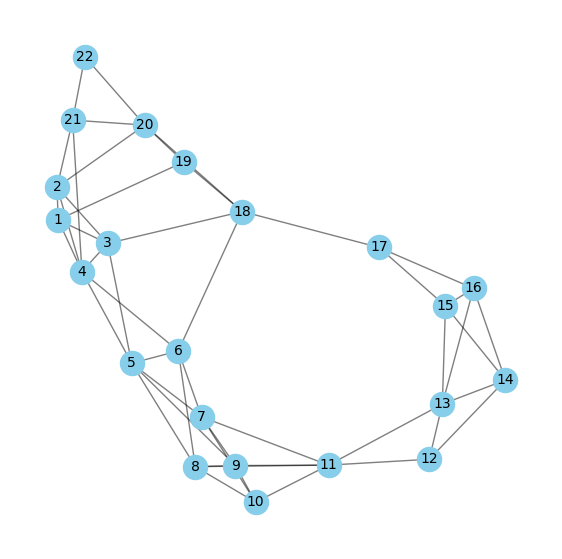

In [191]:
drawed_graphs_path = files_handler_obj.make_dir(network_folder_path, "Drawed Graphs")
plot_graph_by_attribute(hyper_graph, save_path=drawed_graphs_path, file_name="01-Hyper Graph")

In [192]:
att_name = "anchor_score"

In [193]:
hyper_graph, anchor_set, anchor_score = find_anchor_nodes(hyper_graph, att_name=att_name)
len(anchor_set), len(anchor_score)

(3, 22)

In [194]:
nodes_weights = nx.get_node_attributes(hyper_graph, att_name)
nodes_weights_mean = sum(nodes_weights.values()) / len(nodes_weights)
# print(nodes_weights)
nodes_weights = {k: v for k, v in sorted(nodes_weights.items(), key=lambda item: item[1], reverse=True)}
# nodes_weights

In [195]:
# print(nodes_weights)

In [196]:
def jaccard_similarity(G, u, v):
    Nu = set(G.neighbors(u))
    Nv = set(G.neighbors(v))
    if len(Nu)==0 and len(Nv)==0:
        return 0
    return len(Nu & Nv) / len(Nu | Nv)

def dynamic_jaccard_threshold(G, core_nodes, hop=2, alpha=0.5):
    pairs = []

    # ایجاد زوج‌های کاندید
    for u, v in combinations(core_nodes, 2):
        try:
            if nx.shortest_path_length(G, u, v) <= hop:
                pairs.append((u, v))
        except:
            continue

    if len(pairs) == 0:
        return 0.1  # fallback

    # محاسبه شباهت
    sims = []
    for u, v in pairs:
        sims.append(jaccard_similarity(G, u, v))

    sims = np.array(sims)
    mu = sims.mean()
    sigma = sims.std()

    # آستانه دینامیک
    T = mu + alpha * sigma

    # جلوگیری از کوچک شدن بیش از حد
    return max(T, 0.1)

def compute_anchor_params(graph: nx.Graph, attribute:str=None):
    """
    Lightweight dynamic parameter selection (safe defaults).
    Returns dict with:
      - max_bfs_hops_for_anchor
      - anchor_merge_hops
      - max_iter
    """
    N = graph.number_of_nodes()
    
    # max hops
    max_hops = int(np.clip(round(math.log10(N)), 2, 6))
    # anchor merge hops: small constant scaled with log
    anchor_merge_hops = int(
        np.clip(max(1, int(round(math.log1p(max(2, N) / 100)))), 1, 3)
    )
    max_iter = 6 if N > 2000 else 4
    return {
        "max_bfs_hops_for_anchor": max_hops,
        "anchor_merge_hops": anchor_merge_hops,
        "max_iter": max_iter,
    }

def combine_anchor_nodes(graph: nx.Graph, anchors:list,
    nodes_weight: dict = None,
    weight_mean: float = None,
    min_jaccard_for_merge: float = None,
    anchor_merge_hops: int = None):
    
    
    # fallback if none found
    if len(anchors) == 0:
        candidates = [n for n in graph.nodes()
            if nodes_weight.get(n, 0) >= weight_mean and graph.degree(n) > 0
        ]
        if len(candidates) == 0:
            topk = sorted(
                graph.nodes(), key=lambda x: nodes_weight.get(x, 0), reverse=True
            )[: max(1, int(0.01 * graph.number_of_nodes()))]
            anchors.extend(topk)
        else:
            anchors.extend(candidates)
    # print(anchors)
    # ---------- Anchor merging: merge anchors close to each other (within anchor_merge_hops) ----------
    # Build union-find for anchor merge
    parent = {a: a for a in anchors}

    def find(x):
        # اگر x در parent نباشد آن را خودِ خودش قرار می‌دهیم (ایمن‌سازی)
        if parent.get(x, x) != x:
            parent[x] = find(parent[x])
        else:
            parent.setdefault(x, x)
        return parent[x]

    def union(a, b):
        pa, pb = find(a), find(b)
        if pa != pb:
            parent[pb] = pa

    def jaccard(u, v):
        Nu = set(graph.neighbors(u))
        Nv = set(graph.neighbors(v))
        inter = len(Nu & Nv)
        uni = len(Nu | Nv)
        return inter / uni if uni > 0 else 0

    if min_jaccard_for_merge is None:
        min_jaccard_for_merge = dynamic_jaccard_threshold(graph, anchors, anchor_merge_hops)
        print("Dynamic Jaccard threshold =", min_jaccard_for_merge)

    # Multi-source BFS from anchors up to anchor_merge_hops to detect proximity among anchors
    if anchor_merge_hops is not None and anchor_merge_hops >= 1 and len(anchors) > 1:
        # BFS from each anchor but we only need to see if anchor reaches anchor
        # We'll do limited BFS starting from every anchor and record distances to other anchors
        for anchor in anchors:
            dq = deque([(anchor, 0)])
            seen = {anchor: 0}
            while dq:
                node, dist = dq.popleft()
                if dist >= anchor_merge_hops:
                    continue
                for neighbor in graph.neighbors(node):
                    if neighbor in seen:
                        continue
                    seen[neighbor] = dist + 1
                    dq.append((neighbor, dist + 1))
                    if neighbor in anchors and neighbor != anchor:
                        r_neighbor, r_anchor = find(neighbor), find(anchor)
                        w_r_neighbor, w_r_anchor = nodes_weight.get(r_neighbor, 0.0), nodes_weight.get(r_anchor, 0.0)

                        # if min(w_r_neighbor, w_r_anchor) / max(w_r_neighbor, w_r_anchor) < weight_similarity_threshold:
                        if jaccard(r_neighbor, r_anchor) > min_jaccard_for_merge:
                            union(anchor, neighbor)
    
    # print(f"parent: {parent}")
    # choose canonical representative for each merged anchor group (highest weight then degree)
    groups = defaultdict(list)
    for a in anchors:
        groups[find(a)].append(a)
    # print(f"groups: {groups}")

    final_anchors = set()
    for rep, members in groups.items():
        best = max(members, key=lambda n: (nodes_weight.get(n, 0), graph.degree(n)))
        final_anchors.add(best)
    anchor_set = set(final_anchors)
    return anchor_set

def propagate_anchor_labels_simple(
        graph: nx.Graph,
        anchor_set: set,
        max_hops: int = 3,
        max_iter: int = 10,
        edge_weight_key: str = "weight"
    ):
    """
    Lightweight anchor-driven multi-label propagation.
    Anchor nodes seed labels but NEVER receive labels from others.
    """

    from collections import defaultdict, Counter, deque

    # -----------------------------------------
    # 1. Initialize Labels
    # -----------------------------------------
    for n in graph.nodes():
        graph.nodes[n]["Labels"] = Counter()

    # anchors seed themselves (only their own label)
    for a in anchor_set:
        graph.nodes[a]["Labels"][a] = 1
        graph.nodes[a]["Relabel"] = True
        graph.nodes[a]["Core"] = True
        graph.nodes[a]["Visited"] = True

    # -----------------------------------------
    # 2. BFS radius limitation for allowed nodes
    # -----------------------------------------
    allowed_nodes = set(anchor_set)
    dq = deque([(a, 0) for a in anchor_set])
    visited = {a: 0 for a in anchor_set}


    while dq:
        u, d = dq.popleft()
        if d >= max_hops:
            continue
        for v in graph.neighbors(u):
            if v not in visited:
                visited[v] = d + 1
                allowed_nodes.add(v)
                dq.append((v, d + 1))

    # -----------------------------------------
    # 3. Synchronous propagation (Waves)
    # -----------------------------------------
    for it in range(max_iter):

        # pending for all non-anchor nodes
        pending = {
            n: Counter() for n in allowed_nodes if n not in anchor_set
        }

        # cast votes
        for u in allowed_nodes:

            u_labels = graph.nodes[u]["Labels"]
            if not u_labels:
                continue

            # u → neighbors
            for v in graph.neighbors(u):

                # skip nodes outside BFS range
                if v not in allowed_nodes:
                    continue

                # ❌ anchor nodes NEVER receive labels
                if v in anchor_set:
                    continue

                w = graph.edges[u, v].get(edge_weight_key, 1.0)

                # propagate u's labels to v
                for lbl, cnt in u_labels.items():
                    pending[v][lbl] += cnt * w
                    graph.nodes[v]["Relabel"] = True
                    graph.nodes[v]["Visited"] = True

        # -----------------------------------------
        # 4. commit new labels ONLY for non-anchor nodes
        # -----------------------------------------
        changed = False

        for n in allowed_nodes:

            # anchors keep their own label only
            if n in anchor_set:
                continue

            if pending[n] and pending[n] != graph.nodes[n]["Labels"]:
                changed = True
                graph.nodes[n]["Labels"] = pending[n]

        if not changed:
            break

    return graph



In [197]:
len(anchor_set), len(anchor_score)

(3, 22)

In [198]:
anchor_params = compute_anchor_params(hyper_graph, att_name)
anchor_params

{'max_bfs_hops_for_anchor': 2, 'anchor_merge_hops': 1, 'max_iter': 4}

In [199]:
anchor_merge_hops = anchor_params['anchor_merge_hops']
anchor_set = combine_anchor_nodes(hyper_graph, anchor_set, nodes_weights, nodes_weights_mean, anchor_merge_hops=anchor_merge_hops)

anchor_set , anchor_params

Dynamic Jaccard threshold = 0.2


({'11', '4', '5'},
 {'max_bfs_hops_for_anchor': 2, 'anchor_merge_hops': 1, 'max_iter': 4})

In [200]:
print(f"Anchor set count: {len(anchor_set)}\nAnchor set list: {anchor_set}")

Anchor set count: 3
Anchor set list: {'5', '11', '4'}


In [201]:
hyper_graph = propagate_anchor_labels_simple(hyper_graph, anchor_set, anchor_params['max_bfs_hops_for_anchor'], anchor_params['max_iter'])
core_nodes = list(anchor_set)
print(f"{len(anchor_set)}: {anchor_set}")

3: {'5', '11', '4'}


In [202]:
for node in hyper_graph.nodes():
    hyper_graph.nodes[node]['Labels'] = dict(hyper_graph.nodes[node]['Labels'])

C:\Users\Frank\AppData\Local\Temp\ipykernel_12988\907916557.py:727: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = plt.cm.get_cmap(cmap, len(all_labels))


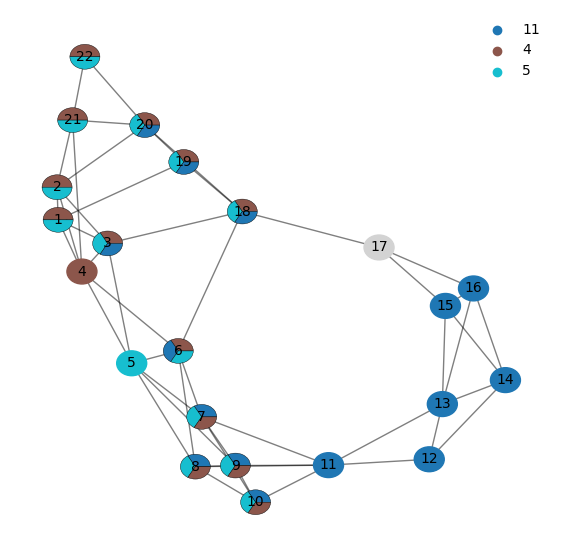

In [203]:
plot_graph_by_labels_(hyper_graph, save_path=drawed_graphs_path, file_name="02-Anchors&LPA")

In [204]:
rw_type = 'Vector'
rw_method = "Frequent Nodes"
embedding_attribute = 'Label'
compression_method = 'lzma'
if embedding_attribute == 'Label' and rw_method == 'Scale':
    sys.exit(0)
if rw_method == "Frequent Nodes":
    rw_length = 512

final_rw_length = 512
embeddings_dimension = 128
walk_depth = 3
if rw_type == 'Vector':
    num_walks = 1
else:
    num_walks = 64
window = 3
min_count = 1
workers = 4
epochs = 100
batch_words = 4
p, q = 1, 0.5,

In [205]:
def load_network_walks(file_info: str, embedding_method: str, embedding_type:str,
                       walk_length: int, walk_depth: int, num_walks: int):
    
    result_file_name = file_info['path'] + file_info['name'] + '/'
    result_file_name += f"{file_info['name']} nodes {embedding_method} random walk {embedding_type}"
    result_file_name += f" walk_length=512 walk_depth={walk_depth} num_walks={num_walks}.xz"
    if os.path.exists(result_file_name):
        with lzma.open(result_file_name, "rt", encoding="utf-8") as f:
            network_walks = json.load(f)
    for node, walk in network_walks.items():
        network_walks[node] = walk[:walk_length]

    return network_walks

def load_word2vec_model(path='walk2vec.model'):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Model not found at {path}")
    model = Word2Vec.load(path)
    print(f"Model loaded from {path}")
    return model

def train_word2vec(all_walks, embedding_size=32, save_path='Word2vec.model', tabs=''):

    model = Word2Vec(
        sentences=all_walks,
        vector_size=embedding_size,  # size of output embeddings
        window=5,
        min_count=0,
        sg=1,             # skip-gram
        workers=4,
        epochs=5
    )
    model.save(save_path)
    print(f"{tabs}{bcolors.green_fg}Word2vec model trained and saved.{bcolors.ENDC}")
    return model

def walk_to_vector(walk, model):
    vectors = []
    for token in walk:
        if token in model.wv:
            vectors.append(model.wv[token])
        else:
            # Optional: handle unknown tokens
            vectors.append(np.zeros(model.vector_size))
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.concatenate(vectors, axis=0)

def make_json_serializable(obj):
    """
    Recursively convert any object (NumPy, PyTorch, etc.) 
    to a JSON-serializable Python type.
    """
    if isinstance(obj, dict):
        return {k: make_json_serializable(v) for k, v in obj.items()}

    elif isinstance(obj, list):
        return [make_json_serializable(v) for v in obj]

    elif isinstance(obj, tuple):
        return tuple(make_json_serializable(v) for v in obj)

    elif isinstance(obj, np.ndarray):
        return obj.tolist()

    elif isinstance(obj, (np.integer,)):
        return int(obj)

    elif isinstance(obj, (np.floating,)):
        return float(obj)

    elif isinstance(obj, torch.Tensor):
        return obj.detach().cpu().tolist()

    elif isinstance(obj, (np.bool_, bool)):
        return bool(obj)

    elif obj is None:
        return None

    else:
        # fallback for unsupported objects
        try:
            json.dumps(obj)  # check if serializable
            return obj
        except TypeError:
            return str(obj)



In [206]:
print(f"{bcolors.yellow_fg}Loading network randome walks...{bcolors.end_color}")
random_walk_load_status, network_random_walks = Random_Walk.load_multilayer_network_nodes_random_walk(file_info, rw_method, rw_type,
                                                              final_rw_length, walk_depth, num_walks,
                                                              compression_method, tabs='\t')
if random_walk_load_status != False:
    print(f"{bcolors.green_fg}Loading randome walks done.{bcolors.end_color}")
else:
    print(f"{bcolors.red_fg}Loading randome walks failed.{bcolors.end_color}")
    sys.exit()
if universal_models == False:
    models_path = file_info['path'] + file_info['name'] + "/"
    models_path = files_handler_obj.make_dir(models_path, "Trained Models")
    print(f"Models save path: {bcolors.underline}{bcolors.cyan_fg}{models_path}{bcolors.end_color}")



Loading network randome walks...
	Nodes random walk loading...
	Load done.
Loading randome walks done.
Models save path: D:/Datasets/CD/Multiplex/My Networks/Gpt Network/Trained Models/


In [207]:
# 1. Train Word2vec model
if os.path.exists(models_path + 'walk2vec.model'):
    print(f"{bcolors.yellow_fg}Load existing Word2vec model...{bcolors.end_color}")
    word2vec_model = Word2Vec.load(models_path + 'walk2vec.model')
    for node, node_walks in network_random_walks.items():
        for layer, walk in node_walks.items():
            network_random_walks[node][layer] = walk[:embeddings_dimension]
    print(f"{bcolors.green_fg}Word2vec Model loading done.{bcolors.end_color}")
else:
    print(f"{bcolors.yellow_fg}Train word2vec model...{bcolors.end_color}")
    all_walks = []
    for node, node_walks in network_random_walks.items():
        for layer, walk in node_walks.items():
            all_walks.append(walk[:embeddings_dimension])
            network_random_walks[node][layer] = walk[:embeddings_dimension]
    word2vec_model = train_word2vec(all_walks, save_path= models_path + 'walk2vec.model')
    del all_walks

# Generate Word2vec Embeddings
word2vec_walks = []
for node, node_walks in network_random_walks.items():
        for layer, walk in node_walks.items():
             temp_word2vec_walks = walk_to_vector(walk, word2vec_model)
             word2vec_walks.append(temp_word2vec_walks)
             network_random_walks[node][layer] = temp_word2vec_walks
word2vec_walks = np.array(word2vec_walks)      
print(f"Word2vec model output shape: {temp_word2vec_walks.shape}")
network_nodes = network_random_walks.keys()

Load existing Word2vec model...
Word2vec Model loading done.
Word2vec model output shape: (4096,)


In [208]:
class Conv1DAutoencoder(nn.Module):
    def __init__(self, input_dim=4096, latent_dim=128):
        super(Conv1DAutoencoder, self).__init__()

        # ---------- Encoder ----------
        # Input [B, 1, 4096]
        # Output [B, 256, 128]
        self.encoder_conv = nn.Sequential(
            nn.Conv1d(
                in_channels=1,
                out_channels=256,
                kernel_size=32,
                stride=32,
                padding=0  # no padding
            ),
            nn.BatchNorm1d(256),
            nn.ReLU()
        )

        # ---------- FC Encoder ----------
        self.fc_enc = nn.Linear(256 * (input_dim // 32), latent_dim)  # 256*128 → 128 latent

        # ---------- FC Decoder ----------
        self.fc_dec = nn.Linear(latent_dim, 256 * (input_dim // 32))  # 128 → 256*128

        # ---------- Decoder ----------
        # Input [B, 256, 128]
        # Output [B, 1, 4096]
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose1d(
                in_channels=256,
                out_channels=1,
                kernel_size=32,
                stride=32,
                padding=0
            ),
            nn.Sigmoid()  # to normalize output [0,1]
        )

    def forward(self, x):
        x = x.unsqueeze(1)  # [B, 1, 4096]

        # Encode
        z = self.encoder_conv(x)              # [B, 256, 128]
        z_flat = z.view(z.size(0), -1)        # [B, 256*128]
        latent = self.fc_enc(z_flat)         # [B, latent_dim]

        # Decode
        z_dec = self.fc_dec(latent)          # [B, 256*128]
        z_dec = z_dec.view(x.size(0), 256, -1)  # [B, 256, 128]
        out = self.decoder_conv(z_dec)       # [B, 1, 4096]

        return out.squeeze(1), latent

def train_convae(model, dataloader, loss_fn, optimizer, save_path,
                 epochs=50, lr=1e-3, device='cuda'):

    model.to(device)
    best_loss = np.inf

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        progress_bar = tqdm(dataloader, desc=f"\tEpoch {epoch+1}", leave=True)
        for batch in progress_bar:
            x = batch[0].to(device)

            optimizer.zero_grad()
            reconstructed, _ = model(x)
            loss = loss_fn(reconstructed, x)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            progress_bar.set_postfix(loss=loss.item())

        avg_loss = running_loss / len(dataloader)
        if avg_loss <= best_loss:
            best_loss = avg_loss
            torch.save(model.state_dict(), save_path+"ConvAE best loss.pt")
            print(f"\t{bcolors.green_fg}Avg Loss: {avg_loss:.6f}{bcolors.ENDC}")
        else:
            print(f"\t{bcolors.red_fg}Avg Loss: {avg_loss:.6f}{bcolors.ENDC}")

    torch.save(model.state_dict(), save_path+"ConvAE.pt")

def load_convae(model, load_path='convae.pth', device='cpu'):
    if os.path.exists(load_path):
        model.load_state_dict(torch.load(load_path, map_location=device))
        model.to(device)
        model.eval()
        print(f"{bcolors.green_fg}Model file found at:{bcolors.ENDC}" +
               f"{bcolors.underline}{bcolors.cyan_fg}{load_path}{bcolors.ENDC}")
    else:
        model = None
        print(f"{bcolors.red_fg}Model file not found at:{bcolors.ENDC}" +
               f"{bcolors.underline}{bcolors.cyan_fg}{load_path}{bcolors.ENDC}")
    # print(f"✅ ConvAE model loaded successfully from: {load_path}")
    return model


In [209]:
# Train ConvAE Model

input_dim = len(word2vec_walks[0])
latent_dim = embeddings_dimension
batch_size = 512
epochs = 50
lr=1e-3
device ='cuda' if torch.cuda.is_available() else 'cpu'

# Initialize model
model = Conv1DAutoencoder(input_dim=input_dim, latent_dim=latent_dim)

# Load trained model
if ConvAE_best_loss == True:
    model = load_convae(model, models_path+'ConvAE best loss.pt', device)
else:
    model = load_convae(model, models_path+'ConvAE.pt', device)
if model == None:
    word2vec_walks = torch.from_numpy(word2vec_walks).to(torch.float32)
    dataset = TensorDataset(word2vec_walks)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # Initialize model
    model = Conv1DAutoencoder(input_dim=input_dim, latent_dim=latent_dim)

    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Train ConvAE
    train_convae(model, dataloader, loss_fn, optimizer, save_path=models_path, epochs=epochs, lr=lr, device=device, )



Model file found at:D:/Datasets/CD/Multiplex/My Networks/Gpt Network/Trained Models/ConvAE best loss.pt


In [210]:
print(f"{bcolors.yellow_fg}Loading hyper graph randome walks...{bcolors.end_color}")
random_walk_load_status, hyper_graph_random_walk_vectors = Random_Walk.load_multilayer_hyper_graph_nodes_random_walk(file_info, rw_method, rw_type,
                                                              final_rw_length, walk_depth, num_walks,
                                                              compression_method, tabs='\t')
if random_walk_load_status != False:
    print(f"{bcolors.green_fg}Loading randome walks done.{bcolors.end_color}")
else:
    print(f"{bcolors.red_fg}Loading randome walks failed.{bcolors.end_color}")
    hyper_graph_random_walk_vectors = Random_Walk.graph_random_walk_vector(hyper_graph, final_rw_length, walk_depth, embedding_attribute)

    Random_Walk.write_multilayer_hyper_graph_nodes_random_walk(hyper_graph_random_walk_vectors, file_info,
                                                   rw_method, rw_type,
                                                   final_rw_length, walk_depth, num_walks,
                                                   compression_method, '\t')

for node, walk in hyper_graph_random_walk_vectors.items():
    hyper_graph_random_walk_vectors[node] = walk[:embeddings_dimension]

word2vec_walks = []
for node, walk in hyper_graph_random_walk_vectors.items():
    hyper_graph_random_walk_vectors[node] = walk_to_vector(walk, word2vec_model)
word2vec_walks = np.array(list(hyper_graph_random_walk_vectors.values()))
print(f"Word2vec model output shape: {temp_word2vec_walks.shape}")

if universal_models == False:
    models_path = file_info['path'] + file_info['name'] + "/"
    models_path = files_handler_obj.make_dir(models_path, "Trained Models")
    print(f"Models save path: {bcolors.underline}{bcolors.cyan_fg}{models_path}{bcolors.end_color}")



Loading hyper graph randome walks...
	Nodes random walk loading...
	Load done.
Loading randome walks done.
Word2vec model output shape: (4096,)
Models save path: D:/Datasets/CD/Multiplex/My Networks/Gpt Network/Trained Models/


In [211]:
warnings.filterwarnings("ignore", category=FutureWarning)
save_path = file_info['path'] + file_info['name'] + '/'
print(f"{bcolors.yellow_fg}Encode to 128-d embeddings by Conv1DAutoencoder...{bcolors.end_color}")
# Encode to 128-d embeddings
with torch.no_grad():
    pbar = tqdm(total=len(hyper_graph_random_walk_vectors))
    i = 0
    for node, _ in hyper_graph_random_walk_vectors.items():
        pbar.set_description(f"Node {node:10}")
        walk = word2vec_walks[i]
        if type(walk) == torch.Tensor:
            walk = walk.to(torch.float32)
        else:
            walk = torch.from_numpy(walk).to(torch.float32).unsqueeze(0)
        _, temp_embedding = model(walk.to(device))
        hyper_graph_random_walk_vectors[node] = temp_embedding.squeeze()
        pbar.update(1)
        i += 1
    pbar.close()

print("Compressed embeddings shape:", temp_embedding.squeeze().shape)
del word2vec_walks


Encode to 128-d embeddings by Conv1DAutoencoder...


Node 22        : 100%|██████████| 22/22 [00:00<00:00, 177.85it/s]

Compressed embeddings shape: torch.Size([128])


In [212]:
def refine_mistake_labels(graph):
    for node in graph.nodes():
        node_lbl = list(graph.nodes[node]['Labels'].keys())[0]
        nbrs = graph.neighbors(node)
        lbl_flag = False
        nbr_lbls = {}
        for nbr in nbrs:
            nbr_lbl = list(graph.nodes[nbr]['Labels'].keys())[0]
            if node_lbl == nbr_lbl:
                lbl_flag = True
                break
            if nbr_lbl in nbr_lbls.keys():
                nbr_lbls[nbr_lbl] += 1
            else:
                nbr_lbls[nbr_lbl] = 1
        if lbl_flag == False:
            ferquent_lbl = max(nbr_lbls, key=nbr_lbls.get)
            graph.nodes[node]['Labels'] = {ferquent_lbl:1}
    return graph

def get_neghbore_lbl(graph, node):
    """
    Finds the closest neighbor (in BFS order) that already has a Label.
    Returns the label and assigns it to 'node'.
    """

    # اگر نود خودش لیبل دارد، همان را برگردان
    if len(graph.nodes[node]["Labels"]) > 0:
        return list(graph.nodes[node]["Labels"].keys())[0]

    visited = set()
    q = deque([node])
    visited.add(node)

    while q:
        current = q.popleft()

        for nbr in graph.neighbors(current):
            if nbr in visited:
                continue
            visited.add(nbr)

            # اگر همسایه لیبل دارد → همین را استفاده کن
            if len(graph.nodes[nbr]["Labels"]) > 0:
                lbl = list(graph.nodes[nbr]["Labels"].keys())[0]
                graph.nodes[node]["Labels"] = {lbl: 1}
                return lbl

            q.append(nbr)

    # اگر هیچ لیبلی در کل کامپوننت نبود
    return node

def refine_labels_weighted(graph, graph_random_walk_vectors,):

    nodes_labels = nx.get_node_attributes(graph, "Labels")

    for node, labels in nodes_labels.items():
        # ------------------------------------------------------
        # 2) نودهایی با چند لیبل → انتخاب نزدیک‌ترین core
        # ------------------------------------------------------
        if len(labels) > 1:
            distance_dict = {}
            a = np.array(graph_random_walk_vectors[node])

            for core_node, freq in labels.items():
                b = np.array(graph_random_walk_vectors[core_node])
                distance_dict[core_node] = np.mean(np.abs(a - b)) / freq

            best = min(distance_dict, key=distance_dict.get)
            graph.nodes[node]['Labels'] = {str(best): 1}

    
    for node in graph.nodes():
        if len(graph.nodes[node]['Labels']) == 0 :
            graph.nodes[node]['Labels'] = {get_neghbore_lbl(graph, node): 1}
        if list(graph.nodes[node]['Labels'].keys())[0]== 'None':
            graph.nodes[node]['Labels'] = {get_neghbore_lbl(graph, node): 1}
    
    # graph = refine_mistake_labels(graph)

    return graph


In [213]:
hyper_graph = refine_labels_weighted(hyper_graph, hyper_graph_random_walk_vectors)

C:\Users\Frank\AppData\Local\Temp\ipykernel_12988\907916557.py:727: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = plt.cm.get_cmap(cmap, len(all_labels))


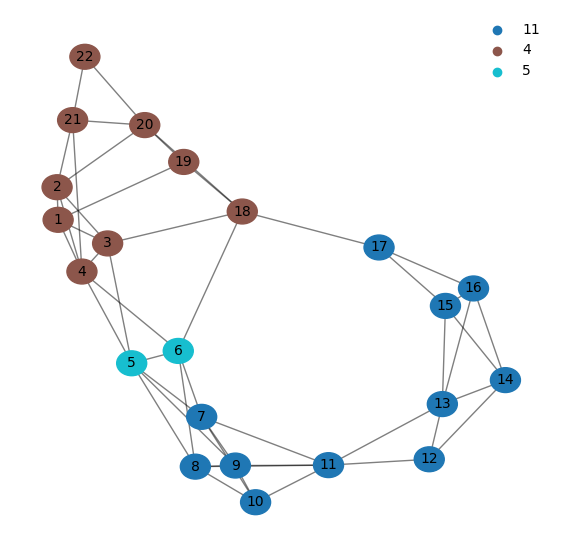

In [214]:
plot_graph_by_labels_(hyper_graph, save_path=drawed_graphs_path, file_name="03-Refine Labels")

In [215]:
def get_communities_info(graph:nx.Graph, comm_lbl:str):
    communities = {} # Bucketing nodes by their communities
    nodes_communities = {} # This will create a dictionary where keys are Node Id and values are community.

    nodes_lable = nx.get_node_attributes(graph, comm_lbl)
    for node, lbl in nodes_lable.items():
        if type(lbl) == dict:
            nodes_communities[node] = list(lbl.keys())[0]  # Assuming each node has only one label
            try:
                community = list(lbl.keys())[0]
                graph.nodes[node]['Labels'] = community
                
            except:
                print(i, node, lbl)
        elif type(lbl) == str or type(lbl) == int:
            nodes_communities[node] = lbl
            community = lbl
        else:
            sys.exit("Node Label Unknown.")

        if community in communities.keys():
            communities[community].append(node)
        else:
            communities[community] =[]
            communities[community].append(node)
    return communities, nodes_communities

def evaluate_communities(G, communities):
    """
    communities: list of sets (or lists) of nodes
    returns: dict of evaluation metrics (no ground truth needed)
    """

    # --- تبدیل به فرمت sets ---
    communities = [set(c) for c in communities]

    # --- معیارهای NetworkX ---
    modularity = community.modularity(G, communities)
    coverage, performance = community.partition_quality(G, communities)

    # -----------------------------------------------------------
    # 1) Conductance
    # -----------------------------------------------------------
    def conductance(G, C):
        if len(C) <= 1 or len(C) == G.number_of_nodes():
            return 0
        else:
            return nx.algorithms.cuts.conductance(G, C)

    conductance_list = [conductance(G, c) for c in communities]

    # -----------------------------------------------------------
    # 2) Cut Ratio
    # -----------------------------------------------------------
    def cut_ratio(G, C):
        cut_edges = nx.algorithms.cuts.cut_size(G, C)
        k = len(C)
        n = len(G)
        if k == 0 or k == n:
            return 0
        return cut_edges / (k * (n - k))

    cut_ratio_list = [cut_ratio(G, c) for c in communities]

    # -----------------------------------------------------------
    # 3) Expansion
    # -----------------------------------------------------------
    def expansion(G, C):
        cut_edges = nx.algorithms.cuts.cut_size(G, C)
        if len(C) == 0:
            return 0
        return cut_edges / len(C)

    expansion_list = [expansion(G, c) for c in communities]

    # -----------------------------------------------------------
    # 4) Internal Density
    # -----------------------------------------------------------
    def internal_density(G, C):
        subG = G.subgraph(C)
        m = subG.number_of_edges()
        n = len(subG)
        if n <= 1:
            return 0
        return (2*m) / (n*(n-1))

    internal_density_list = [internal_density(G, c) for c in communities]

    # -----------------------------------------------------------
    # 5) Edges Inside
    # -----------------------------------------------------------
    def edges_inside(G, C):
        return G.subgraph(C).number_of_edges()

    edges_inside_list = [edges_inside(G, c) for c in communities]

    # -----------------------------------------------------------
    # 6) Edges Outside
    # -----------------------------------------------------------
    def edges_outside(G, C):
        return nx.algorithms.cuts.cut_size(G, C)

    edges_outside_list = [edges_outside(G, c) for c in communities]

    # -----------------------------------------------------------
    # 7) Avg Internal Degree
    # -----------------------------------------------------------
    def avg_internal_degree(G, C):
        subG = G.subgraph(C)
        if len(C) == 0:
            return 0
        return sum(dict(subG.degree()).values()) / len(C)

    avg_internal_degree_list = [avg_internal_degree(G, c) for c in communities]

    # -----------------------------------------------------------
    # 8) Avg External Degree
    # -----------------------------------------------------------
    def avg_external_degree(G, C):
        total = 0
        for u in C:
            for v in G.neighbors(u):
                if v not in C:
                    total += 1
        if len(C) == 0:
            return 0
        return total / len(C)

    avg_external_degree_list = [avg_external_degree(G, c) for c in communities]

    # -----------------------------------------------------------
    # خروجی کامل
    # -----------------------------------------------------------
    return {
        "num_communities": len(communities),

        # NetworkX metrics
        "modularity": modularity,
        "coverage": coverage,
        "performance": performance,

        # Conductance-based
        # "conductance_per_comm": conductance_list,
        "avg_conductance": sum(conductance_list)/len(conductance_list),

        # Cut Ratio
        # "cut_ratio_per_comm": cut_ratio_list,
        "avg_cut_ratio": sum(cut_ratio_list)/len(cut_ratio_list),

        # Expansion
        # "expansion_per_comm": expansion_list,
        "avg_expansion": sum(expansion_list)/len(expansion_list),

        # Internal Density
        # "internal_density_per_comm": internal_density_list,
        "avg_internal_density": sum(internal_density_list)/len(internal_density_list),

        # Edges Inside
        # "edges_inside_per_comm": edges_inside_list,
        "avg_edges_inside": sum(edges_inside_list)/len(edges_inside_list),

        # Edges Outside (cut edges)
        # "edges_outside_per_comm": edges_outside_list,
        "avg_edges_outside": sum(edges_outside_list)/len(edges_outside_list),

        # Avg Internal Degree
        # "avg_internal_degree_per_comm": avg_internal_degree_list,
        "avg_internal_degree": sum(avg_internal_degree_list)/len(avg_internal_degree_list),

        # Avg External Degree
        # "avg_external_degree_per_comm": avg_external_degree_list,
        "avg_external_degree": sum(avg_external_degree_list)/len(avg_external_degree_list),
    }

def merge_communities(edge_list, partition, threshold=0.2):
    # کامیونیتی‌ها
    communities = set(partition.values())

    # شمارش یال‌های بین کامیونیتی‌ها
    inter = defaultdict(int)
    inter_sum = defaultdict(int)

    for u, v in edge_list:
        cu, cv = partition[u], partition[v]
        if cu != cv:
            pair = tuple(sorted((cu, cv)))
            inter[pair] += 1
            inter_sum[cu] += 1
            inter_sum[cv] += 1

    # محاسبه NICC
    nicc = {}
    for (c1, c2), w in inter.items():
        nicc[(c1, c2)] = w / (inter_sum[c1] + inter_sum[c2])

    # union-find برای ادغام
    parent = {c: c for c in communities}
    
    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x
    
    def union(a, b):
        pa, pb = find(a), find(b)
        if pa != pb:
            parent[pb] = pa

    # ادغام بر اساس NICC
    for (c1, c2), s in nicc.items():
        if s >= threshold:
            union(c1, c2)

    # آپدیت پارنشین نهایی
    new_partition = {node: find(partition[node]) for node in partition}
    return new_partition

def merge_communities_weighted(edge_list, partition, threshold_min=0.1, threshold_max=0.3):
    """
    edge_list: لیستی از یال‌ها به صورت (u, v, w)
    partition: دیکشنری {node: community_id}
    """

    communities = set(partition.values())

    # شمارش یال‌های بین کامیونیتی‌ها
    inter = defaultdict(float)
    inter_sum = defaultdict(float)

    for u, v, w in edge_list:
        cu, cv = partition[u], partition[v]

        if cu != cv:
            pair = tuple(sorted((cu, cv)))
            inter[pair] += w
            inter_sum[cu] += w
            inter_sum[cv] += w

    # محاسبه NICC برای هر جفت کامیونیتی
    nicc = {}
    for (c1, c2), w in inter.items():
        nicc[(c1, c2)] = w / (inter_sum[c1] + inter_sum[c2])

    nicc_values = np.array(list(nicc.values()))

    # ---------------------------
    # 🎯 انتخاب داینامیک threshold
    # ---------------------------
    if len(nicc_values) > 0:
        mean_nicc = np.mean(nicc_values)
        std_nicc = np.std(nicc_values)

        threshold = mean_nicc + 0.25 * std_nicc
        threshold = float(np.clip(threshold, threshold_min, threshold_max))
    else:
        threshold = threshold_min

    print(f"Dynamic threshold selected = {threshold:.4f}")

    # union-find
    parent = {c: c for c in communities}
    
    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x
    
    def union(a, b):
        pa, pb = find(a), find(b)
        if pa != pb:
            parent[pb] = pa

    # انجام ادغام
    for (c1, c2), score in nicc.items():
        if score >= threshold:
            union(c1, c2)

    # تولید پارتیشن جدید
    new_partition = {node: find(partition[node]) for node in partition}

    return new_partition, threshold


In [216]:
communities, nodes_communities = get_communities_info(hyper_graph, "Labels")
len(communities), len(nodes_communities)

(3, 22)

In [217]:
# for comm_id, comm_nodes in communities.items():
#     print(f"Community {comm_id}  with {len(comm_nodes)} nodes. {comm_nodes}")

In [218]:
def louvain_phase1_from_lpa(G, partitions, weight="weight", tol=1e-12):
    """
    Exact Louvain Phase-1 (node moving), warm-started from LPA partitions.
    """

    # --- init ---
    node2com = {}
    for cid, comm in enumerate(partitions):
        for n in comm:
            node2com[n] = cid

    m = G.size(weight=weight)
    if m == 0:
        return partitions

    # weighted degree
    k = dict(G.degree(weight=weight))

    # Σ_tot per community
    sigma_tot = defaultdict(float)
    for n, c in node2com.items():
        sigma_tot[c] += k[n]

    improved = True

    while improved:
        improved = False

        for node in G.nodes():
            ci = node2com[node]
            ki = k[node]

            # compute k_i,in for neighboring communities
            neigh_com_w = defaultdict(float)
            for nbr, data in G[node].items():
                w = data.get(weight, 1.0)
                neigh_com_w[node2com[nbr]] += w

            # remove node from its community
            sigma_tot[ci] -= ki
            node2com[node] = -1

            best_com = ci
            best_gain = 0.0

            for cj, ki_in in neigh_com_w.items():
                gain = (
                    ki_in / m
                    - (sigma_tot[cj] * ki) / (2 * m * m)
                )

                if gain > best_gain + tol:
                    best_gain = gain
                    best_com = cj

            # reinsert
            node2com[node] = best_com
            sigma_tot[best_com] += ki

            if best_com != ci:
                improved = True

    # --- rebuild communities ---
    final = defaultdict(list)
    for n, c in node2com.items():
        final[c].append(n)

    return list(final.values())


In [219]:
evaluate_metrics = evaluate_communities(hyper_graph, list(communities.values()))
print(evaluate_metrics)

{'num_communities': 3, 'modularity': 0.4107233955718804, 'coverage': 0.7959183673469388, 'performance': 0.7272727272727273, 'avg_conductance': 0.3571289821289822, 'avg_cut_ratio': 0.10577393986484895, 'avg_expansion': 1.8670033670033668, 'avg_internal_density': 0.618013468013468, 'avg_edges_inside': 13.0, 'avg_edges_outside': 6.666666666666667, 'avg_internal_degree': 2.865319865319865, 'avg_external_degree': 1.8670033670033668}


In [220]:
new_communities = {}
new_nodes_communities = {}
new_communities_list = louvain_phase1_from_lpa(hyper_graph, list(communities.values()))
for i, item in enumerate(new_communities_list):
    new_communities[i] = item
    for node in item:
        new_nodes_communities[node] = i
len(new_communities), len(new_nodes_communities)

(3, 22)

In [221]:
# new_communities, new_nodes_communities = get_communities_info(hyper_graph, "Final_Labels")
# len(new_communities), len(new_nodes_communities)


In [222]:
new_evaluate_metrics = evaluate_communities(hyper_graph, list(new_communities.values()))
print(new_evaluate_metrics)

{'num_communities': 3, 'modularity': 0.4590858075706561, 'coverage': 0.7755102040816326, 'performance': 0.7532467532467533, 'avg_conductance': 0.305331941959849, 'avg_cut_ratio': 0.09216899085320139, 'avg_expansion': 1.52962962962963, 'avg_internal_density': 0.6240740740740741, 'avg_edges_inside': 12.666666666666666, 'avg_edges_outside': 7.333333333333333, 'avg_internal_degree': 3.125925925925926, 'avg_external_degree': 1.52962962962963}


In [223]:
if new_evaluate_metrics['modularity'] >= evaluate_metrics['modularity']:
    communities, nodes_communities = new_communities, new_nodes_communities
    print(new_evaluate_metrics)
else:
    print(evaluate_metrics)

{'num_communities': 3, 'modularity': 0.4590858075706561, 'coverage': 0.7755102040816326, 'performance': 0.7532467532467533, 'avg_conductance': 0.305331941959849, 'avg_cut_ratio': 0.09216899085320139, 'avg_expansion': 1.52962962962963, 'avg_internal_density': 0.6240740740740741, 'avg_edges_inside': 12.666666666666666, 'avg_edges_outside': 7.333333333333333, 'avg_internal_degree': 3.125925925925926, 'avg_external_degree': 1.52962962962963}


In [225]:
network_name = "_".join(file_info['name'].split("_")[:-1])
communities_path = files_handler_obj.make_dir(file_info['path'], "Communities Files")
with open(f"{communities_path}/{method_name}.json", 'w') as fp:
    json.dump(nodes_communities, fp)

In [232]:
anchor_labels = {}
for ancher_node in anchor_set:
    anchor_labels[new_nodes_communities[ancher_node]] = ancher_node
anchor_labels

{1: '5', 2: '11', 0: '4'}

C:\Users\Frank\AppData\Local\Temp\ipykernel_12988\464249220.py:728: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = plt.cm.get_cmap(cmap, len(all_labels))


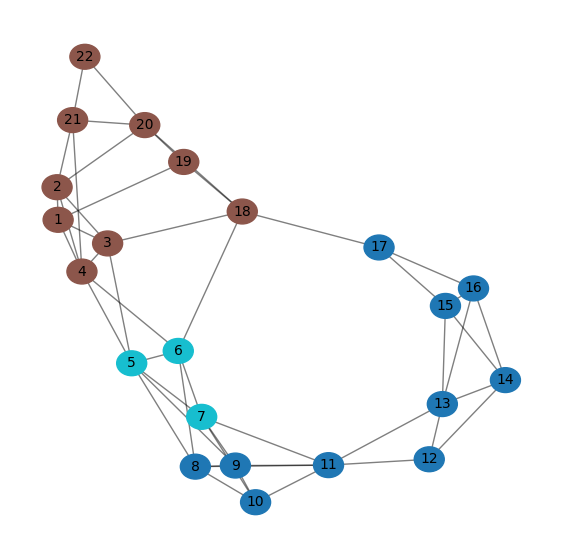

In [233]:

nx.set_node_attributes(hyper_graph, {None}, "Labels")
for node, comm in new_nodes_communities.items():
    hyper_graph.nodes[node]["Labels"] = Counter()
    hyper_graph.nodes[node]["Labels"][anchor_labels[comm]] = 1
plot_graph_by_labels_(hyper_graph, save_path=drawed_graphs_path, file_name="04-Final Communities", plt_legend=False)

In [227]:
# os.system('shutdown -s')

In [228]:
import winsound
winsound.Beep(500, 750)